# Generating a gyrotropic zero mean flow tri-maxwellian distribution

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import h5py
import fipcore as fpc
import pyspedas
from pyspedas.projects import mms

In [2]:
trange = ['2015-12-09/05:03:55', '2015-12-09/05:03:59']

In [ ]:
species = 'e'
bin_width_frac = 0.25
data_dir = os.path.join("..", "data")
subtract_f0 = False
type_tag = 'df' if subtract_f0 else 'f'
hfile_pref = f'fpc_mrx_{type_tag}_{species}_{bin_width_frac:.2f}'
hfile = os.path.join(data_dir, fpc.mms_name_make(hfile_pref, trange[0], trange[1]))

In [4]:
hfile

'../data/mms_fpc_e_0.25_20151209_050355_050359.h5'

In [5]:
with h5py.File(hfile, "r") as f:
    ntime = f["meta"]["time"][:]
    vv_fac = f["fac"]["vv"][:] 

KeyError: "Unable to synchronously open object (object 'vv' doesn't exist)"

In [6]:
import numpy as np
from scipy.constants import c, physical_constants
from pyspedas import get_data, tplot_rename
from pyspedas.projects import mms

def equilibrium_vdf(vv_fac, trange, species='e', probe='1', data_rate='brst', 
            level='l2', get_support_data=True, no_update=False, v_flow=None):
    fpi_vars = mms.fpi(trange=trange, probe=probe, data_rate=data_rate, level=level,
        datatype=[f'd{species}s-moms'], time_clip=True, 
        varnames=[f'mms1_d{species}s_temppara_brst', f'mms1_d{species}s_tempperp_brst', 
        f'mms1_d{species}s_numberdensity_brst'], get_support_data=get_support_data, 
        no_update=no_update)

    tplot_rename(f'mms1_d{species}s_temppara_brst', 't_para')
    tplot_rename(f'mms1_d{species}s_tempperp_brst', 't_perp')
    tplot_rename(f'mms1_d{species}s_numberdensity_brst', 'den')

    # Extract arrays from tplot
    _, den = get_data('den')    # Shape: (ntime,)
    _, t_para = get_data('t_para')    # Shape: (ntime,)
    _, t_perp = get_data('t_perp')    # Shape: (ntime,)

        # Mass constants in MeV converted to eV
    if species.lower() == 'ion':
        mc2_ev = physical_constants['proton mass energy equivalent in MeV'][0] * 1e6
    elif species.lower() == 'e':
        mc2_ev = physical_constants['electron mass energy equivalent in MeV'][0] * 1e6
    else:
        raise ValueError("Species must be 'ion' or 'e'")

    c_km_s = c * 1e-3  # Speed of light in km/s
    
    # Calculate separate parallel and perpendicular thermal velocities (km/s)
    w_para = c_km_s * np.sqrt(2.0 * t_para / mc2_ev)  # Shape: (ntime,)
    w_perp = c_km_s * np.sqrt(2.0 * t_perp / mc2_ev)  # Shape: (ntime,)

    # Extract velocity components from the vv_fac(3, 16384, ntime) 
    v_x = vv_fac[0, :, :]  # Shape: (16384, ntime)
    v_y = vv_fac[1, :, :]  # Shape: (16384, ntime)
    v_z = vv_fac[2, :, :]  # Shape: (16384, ntime)

    # Expects v_flow as a 1D array/list of shape (3,) or a 2D array of shape (3, ntime)
    if v_flow is not None:
        v_x = v_x - v_flow[0]
        v_y = v_y - v_flow[1]
        v_z = v_z - v_flow[2]

    v_perp_sq = v_x**2 + v_y**2  # Shape: (16384, ntime)
    v_para_sq = v_z**2           # Shape: (16384, ntime)

    # Setting up Tri-Maxwellian
    amplitude = den / ((np.pi**1.5) * (w_perp**2) * w_para) # Shape: (ntime,)
    exponent = -(v_perp_sq / (w_perp**2)) - (v_para_sq / (w_para**2))
    vdf_eq = amplitude * np.exp(exponent)
    
    return vdf_eq

In [7]:
equilibrium_vdf(vv_fac, trange)

NameError: name 'vv_fac' is not defined

# Testing out if the new sav file is the same as old one after integrating this maxwellian subtraction

In [ ]:
type_tag = 'f'
hfile_pref = f'fpc_mrx_{type_tag}_{species}_{bin_width_frac:.2f}'
hfile1 = os.path.join(data_dir, fpc.mms_name_make(hfile_pref, trange[0], trange[1]))

In [9]:
hfile, hfile1

('../data/mms_fpc_e_0.25_20151209_050355_050359.h5',
 '../data/mms_fpc_f_e_0.25_20151209_050355_050359.h5')

In [11]:
with h5py.File(hfile, "r") as f:
    ntime = f["meta"]["time"][:]
    vv_fac = f["fac"]["vv"][:] 
    vdf_vol = f["gse"]["vdf_vol"][:]

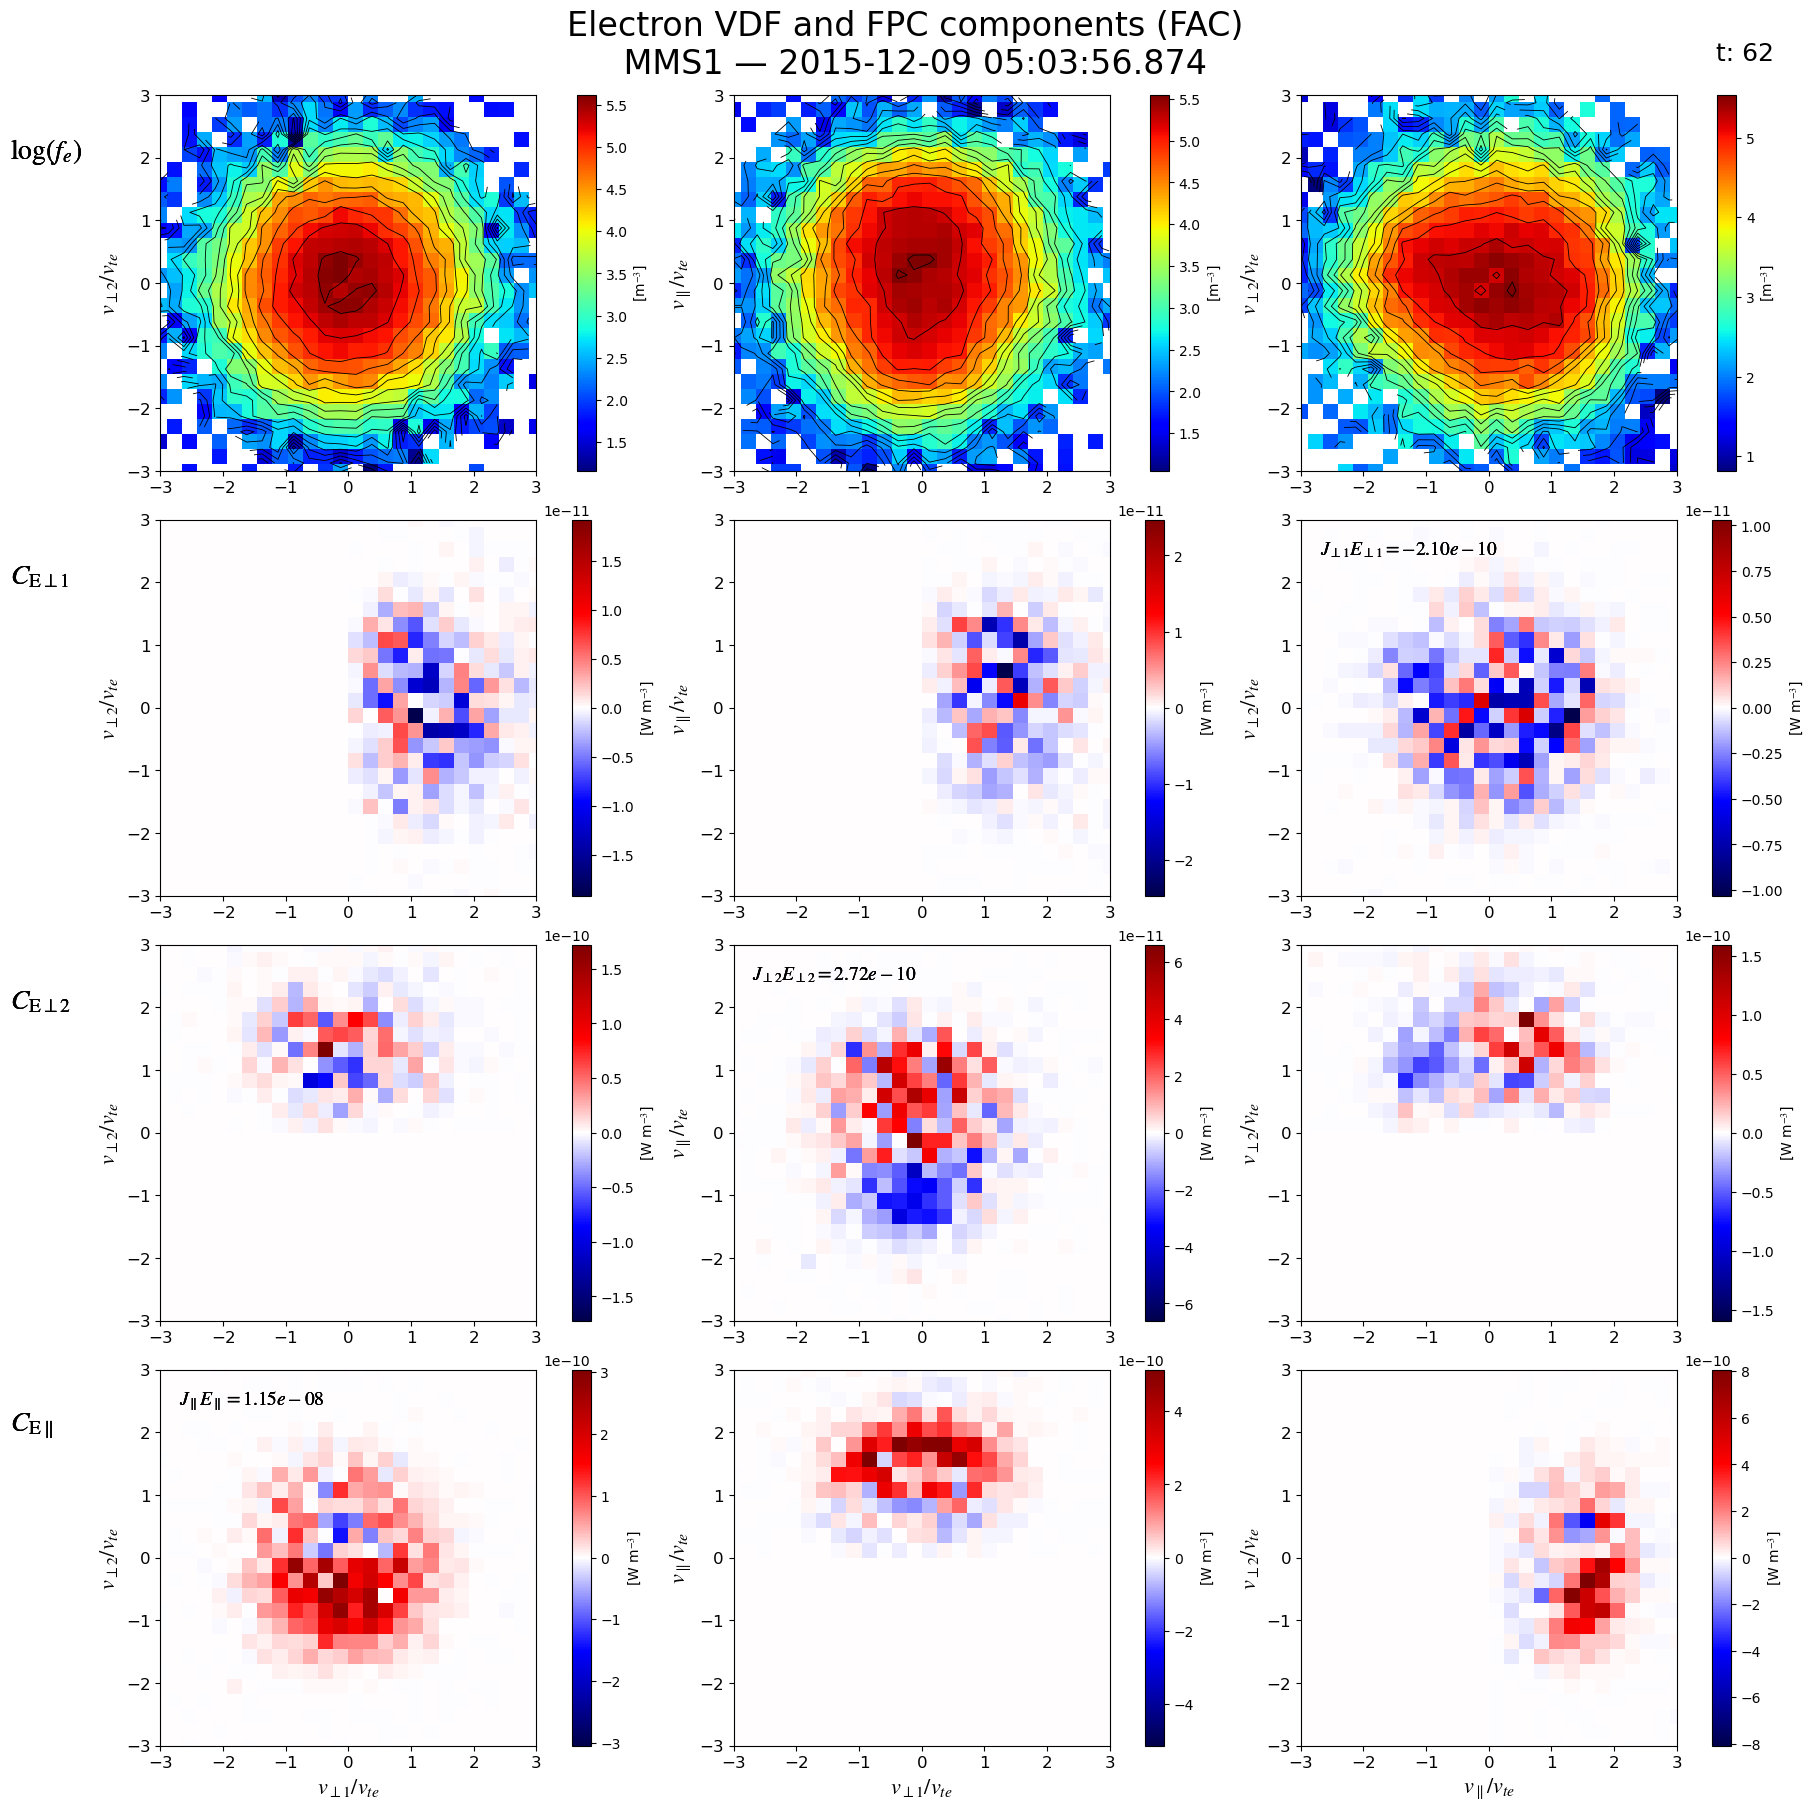

In [15]:
fpc.imagecont_vdf_fpcfold(trange, species='e', bin_width_frac=0.25, time_index = 62,
        coord_type='fac', suptitle_sfx='', dpi_val=100, axis_fntsz=16, 
        cbar_ht=0.050, save_fig=False, outdir_sfx='', show_tind=True)